In [3]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import os as os

print(os.getcwd())


c:\Users\estef\OneDrive\Documentos\analisis-ventas-colombia\notebook


In [4]:
df = pd.read_csv('../data/raw/sample_superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.shape

(9994, 21)

In [13]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [17]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [30]:
columns_text=df.select_dtypes(include='str').columns

for col in columns_text:
    field_empty= (df[col].str.strip()=='').sum()
    if field_empty>0:
        print(f'la columa {col} tiene {field_empty} campos vacios')

print("Revision completa")

Revision completa


In [33]:
duplicated_row=df.duplicated().sum()
print(f'El número de filas duplicadas es {duplicated_row}')

El número de filas duplicadas es 0


In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


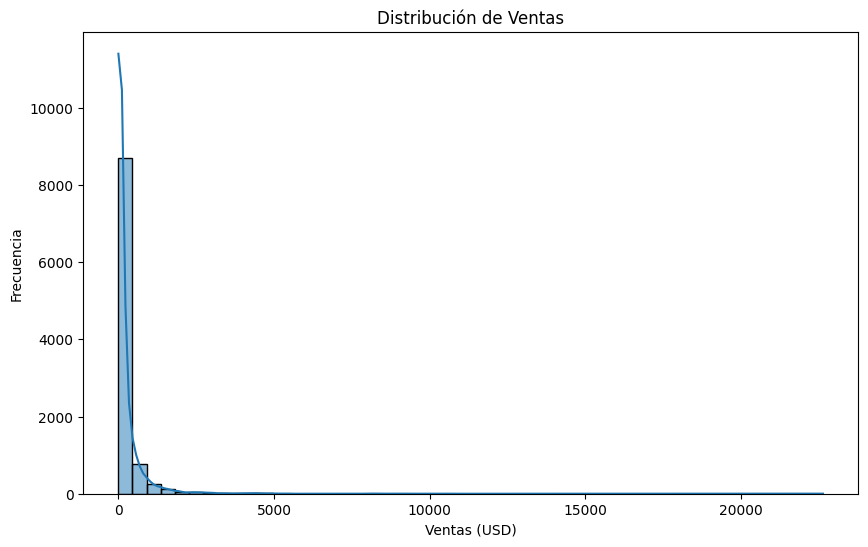

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(df['Sales'], bins=50, kde=True)   
plt.title('Distribución de Ventas')
plt.xlabel('Ventas (USD)')
plt.ylabel('Frecuencia')
plt.show()


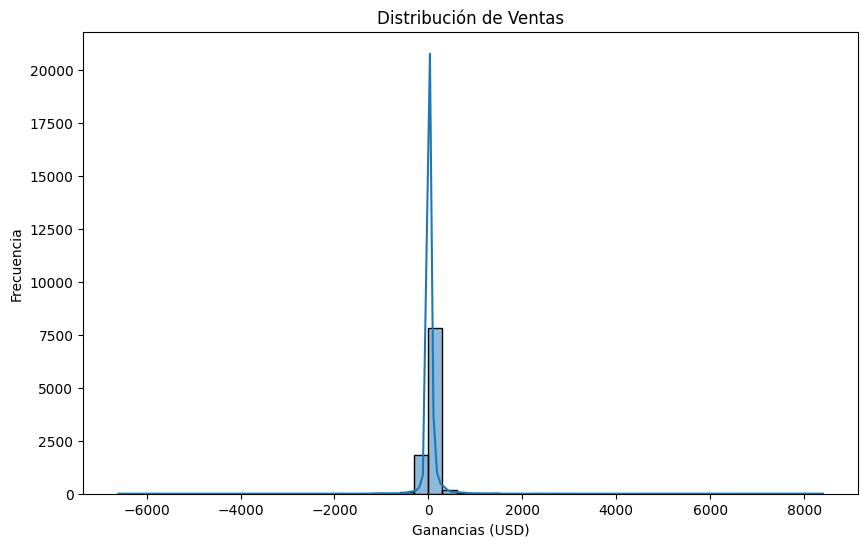

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df['Profit'], bins=50, kde=True)   
plt.title('Distribución de Ventas')
plt.xlabel('Ganancias (USD)')
plt.ylabel('Frecuencia')
plt.show()


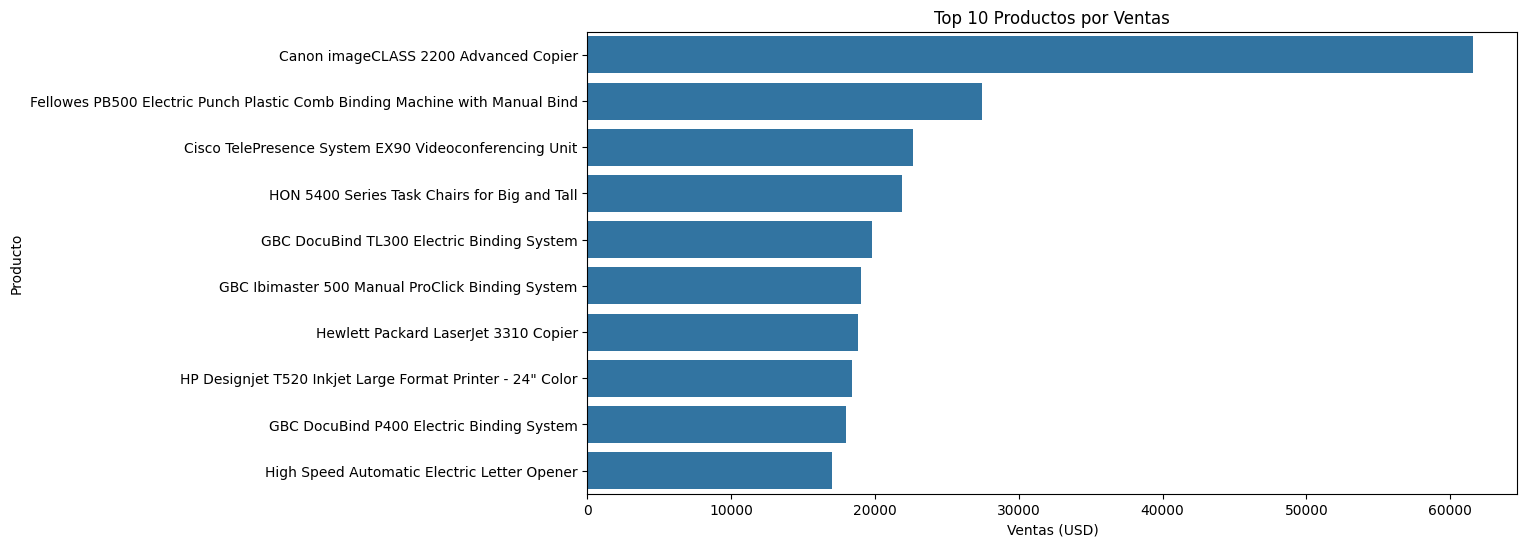

In [5]:
top_products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)


plt.figure(figsize=(12,6))  
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Productos por Ventas')
plt.xlabel('Ventas (USD)')
plt.ylabel('Producto')
plt.show()




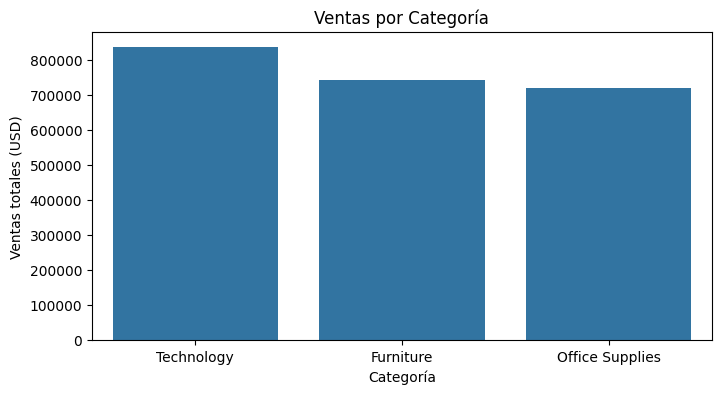

In [ ]:
#Categoria que vendio más

ventas_categoria = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=ventas_categoria.index, y=ventas_categoria.values)
plt.title('Ventas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas totales (USD)')
plt.show()

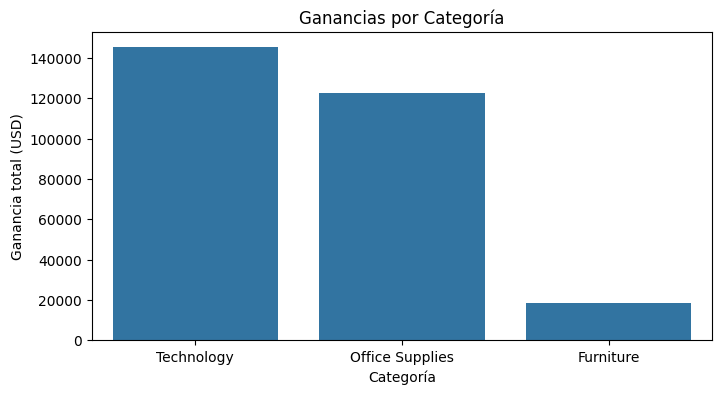

In [9]:
#Categoria que más ganancias tuvo

ganancias_categoria = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=ganancias_categoria.index, y=ganancias_categoria.values)
plt.title('Ganancias por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ganancia total (USD)')
plt.show()


# Furniture: su ganancia en menos, por descuentos muy altos, costos de envio muy altos por tamaño  y precio 

<Figure size 1000x400 with 0 Axes>

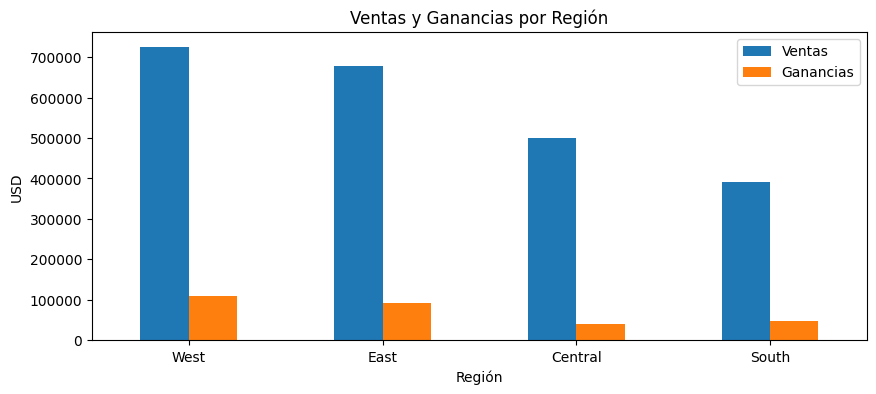

In [17]:
#Azul: Ventas   # Naranja: Ganancias


region_ventas = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

plt.figure(figsize=(10, 4))
region_ventas.plot(kind='bar', figsize=(10, 4))
plt.title('Ventas y Ganancias por Región')
plt.xlabel('Región')
plt.ylabel('USD')
plt.xticks(rotation=0)
plt.legend(['Ventas', 'Ganancias'])
plt.show()

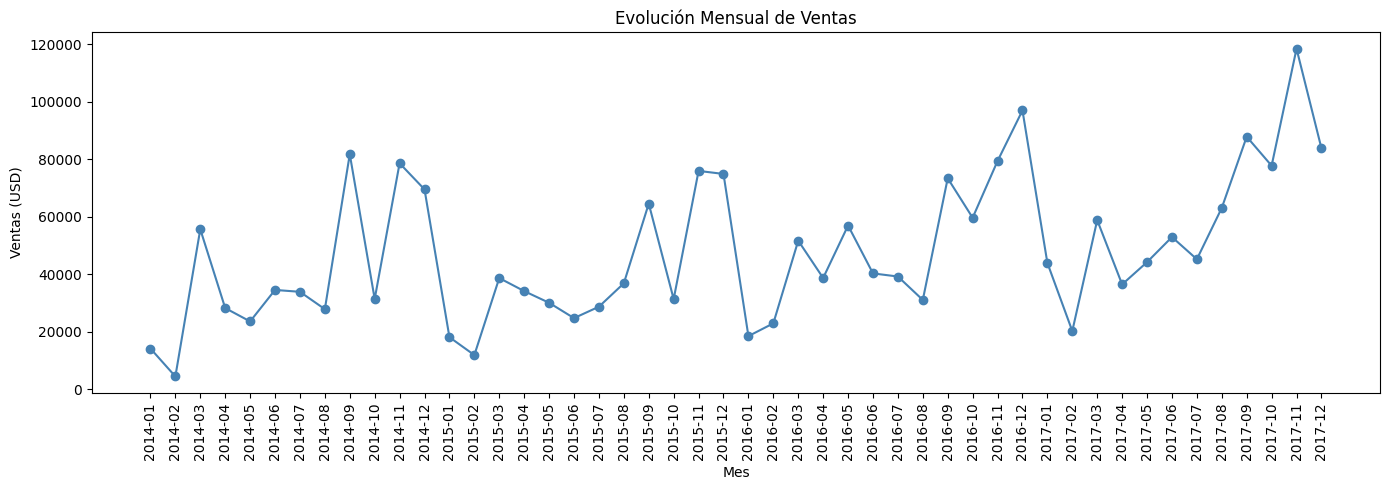

In [19]:
#Evolución mensual de ventas
#Inicio de año (enero-febrero) → ventas bajas, la línea cae
#Fin de año (noviembre-diciembre) → ventas altas, la línea sube

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

ventas_mes = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(ventas_mes.index, ventas_mes.values, marker='o', color='steelblue')
plt.title('Evolución Mensual de Ventas')
plt.xlabel('Mes')
plt.ylabel('Ventas (USD)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

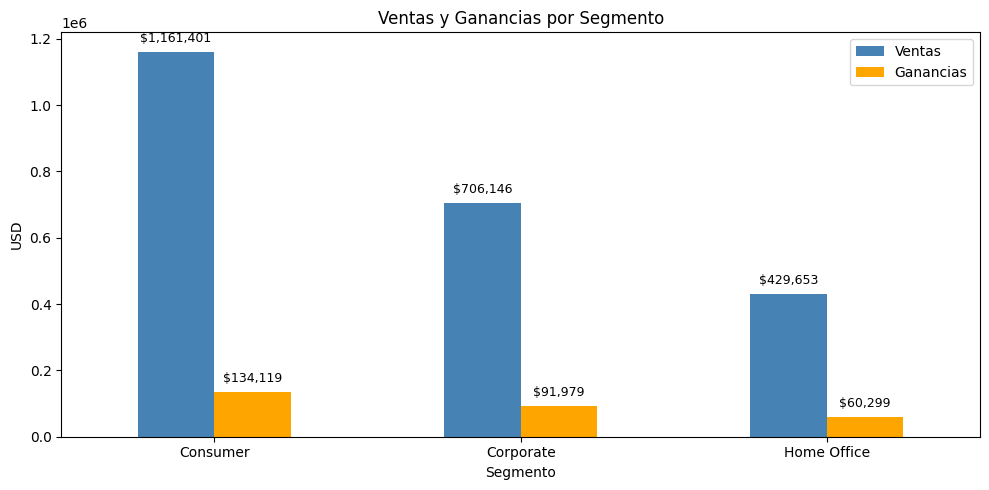

In [22]:
segmento = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

ax = segmento.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'orange'])
plt.title('Ventas y Ganancias por Segmento')
plt.xlabel('Segmento')
plt.ylabel('USD')
plt.xticks(rotation=0)
plt.legend(['Ventas', 'Ganancias'])

# Anotar valores encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', padding=5, fontsize=9)

plt.tight_layout()
plt.show()